In [5]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END,add_messages
from langgraph.checkpoint.sqlite import SqliteSaver

from langgraph.types import Command, interrupt

from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
import os
import re

llm = ChatOllama(model="qwen3:1.7b")

class AgentState(TypedDict):
    messages: Annotated[list,add_messages]

@tool
def transfer_money(amount:int, recipient:str):
    """
    Transfer money. Large transfer require approval.

    Args:
        amount: Amount in dollars
        recipient: Recipient name
    """

    if amount > 1000:
        approval = interrupt(
            {
                "type": "approval_required",
                "amount": amount,
                "recipient": recipient
            }
        )

        if approval.get("decision") != "approve":
            return "Transfer is cancelled!"

    return f"Transferred {amount} to {recipient}"

In [6]:
# =============================================================================
# Guardrail Node - PII Detection
# =============================================================================
# PII Pattern Definitions
patterns = {
        "SSN": r'\b\d{3}-\d{2}-\d{4}\b',  # SSN: 123-45-6789
        "Credit Card": r'\b\d{4}[\s-]?\d{4}[\s-]?\d{4}[\s-]?\d{4}\b',  # Credit Card: 1234-5678-9012-3456
        "Mobile Number": r'\b(\+?\d{1,3}[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}\b',  # Mobile: +1-234-567-8900
        "Email": r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',  # Email: user@example.com
        "URL/Link": r'https?://[^\s]+|www\.[^\s]+'  # URL: http://example.com or www.example.com
    }

def guardrail_node(state:AgentState):
    last_message = state['messages'][-1].content

    for pii_type, pattern in patterns.items():
        if re.search(pattern, last_message):
            return {
                "messages": [SystemMessage(f"Request Blocked: Contains {pii_type}. Please don't share sensitive personal information")]
            }
        
    return {"messages": []}

In [7]:
def agent_node(state:AgentState):

    tools = [transfer_money]

    llm_with_tools = llm.bind_tools(tools)

    system_message = SystemMessage("You are a financial assistant. use transfer_money tool to transfer the money.")

    messages = [system_message] + state['messages']

    response = llm_with_tools.invoke(messages)

    if hasattr(response, 'tool_calls') and response.tool_calls:
        for tc in response.tool_calls:
            print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")
    else:
        print(f"[AGENT] Responding...")

    
    return {"messages": [response]}

def should_continue(state: AgentState):
    last_message = state['messages'][-1]

    if hasattr(last_message,"tool_calls") and last_message.tool_calls:
        return "tools"
    else:
        return END

def guardrail_router(state:AgentState):
    last = state['messages'][-1]

    if isinstance(last,SystemMessage):
        last.pretty_print()
        return END
    
    return "agent"

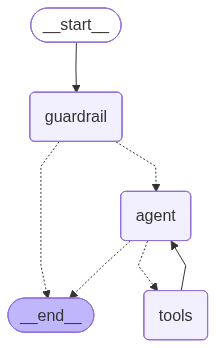

In [9]:
import sqlite3


db_name = "db/approval.db"

os.makedirs('db',exist_ok=True)

conn = sqlite3.connect(db_name,check_same_thread=False)
checkpointer = SqliteSaver(conn)

builder = StateGraph(AgentState)

builder.add_node("agent",agent_node)
builder.add_node("tools",ToolNode([transfer_money]))
builder.add_node("guardrail",guardrail_node)

builder.add_edge(START,"guardrail")
builder.add_conditional_edges("guardrail",guardrail_router,["agent",END])
builder.add_edge("tools","agent")
builder.add_conditional_edges("agent",should_continue,["tools",END])

graph = builder.compile(checkpointer=checkpointer)
graph

In [10]:
config = {"configurable": {'thread_id': 'demo-2'}}

query = "Transfer 500 to laxmi Kant."
result = graph.invoke({
    "messages": [HumanMessage(query)]
}, config)
result

[AGENT] called Tool transfer_money with args {'amount': 500, 'recipient': 'Laxmi Kant'}
[AGENT] Responding...


{'messages': [HumanMessage(content='Transfer 500 to laxmi Kant.', additional_kwargs={}, response_metadata={}, id='fb965b38-3ff4-4236-9d63-ae7756552bf2'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-02T02:52:44.1137219Z', 'done': True, 'done_reason': 'stop', 'total_duration': 16541282700, 'load_duration': 3524492900, 'prompt_eval_count': 179, 'prompt_eval_duration': 4365089200, 'eval_count': 169, 'eval_duration': 8029736400, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019cac76-1c2f-7d71-8111-0ad8d5a4e5a7-0', tool_calls=[{'name': 'transfer_money', 'args': {'amount': 500, 'recipient': 'Laxmi Kant'}, 'id': 'e1efd92f-be34-4a74-8b44-1b481746f6b8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 179, 'output_tokens': 169, 'total_tokens': 348}),
  ToolMessage(content='Transferred 500 to Laxmi Kant', name='transfer_money', id='a913c7fa-7a28-4327-8a37-a7b532

In [11]:
query = "Transfer 5000 to laxmi Kant."
result = graph.invoke({
    "messages": [HumanMessage(query)]
}, config)
result

[AGENT] called Tool transfer_money with args {'amount': 5000, 'recipient': 'Laxmi Kant'}


{'messages': [HumanMessage(content='Transfer 500 to laxmi Kant.', additional_kwargs={}, response_metadata={}, id='fb965b38-3ff4-4236-9d63-ae7756552bf2'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-02T02:52:44.1137219Z', 'done': True, 'done_reason': 'stop', 'total_duration': 16541282700, 'load_duration': 3524492900, 'prompt_eval_count': 179, 'prompt_eval_duration': 4365089200, 'eval_count': 169, 'eval_duration': 8029736400, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019cac76-1c2f-7d71-8111-0ad8d5a4e5a7-0', tool_calls=[{'name': 'transfer_money', 'args': {'amount': 500, 'recipient': 'Laxmi Kant'}, 'id': 'e1efd92f-be34-4a74-8b44-1b481746f6b8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 179, 'output_tokens': 169, 'total_tokens': 348}),
  ToolMessage(content='Transferred 500 to Laxmi Kant', name='transfer_money', id='a913c7fa-7a28-4327-8a37-a7b532

In [12]:
if '__interrupt__' in result:

    interrupt_data = result['__interrupt__'][0]

    result = graph.invoke(
        Command(resume={'decision': input("do you approve or reject?")}),
        config
    )

    result['messages'][-1].pretty_print()

[AGENT] Responding...
================================== Ai Message ==================================

The transfer of $5,000 to Laxmi Kant has been successfully completed. ✨
